# 산업재해 사망사고 데이터 분석

## 1. 데이터 불러오기 및 기본 확인

전처리가 완료된 산업재해 데이터를 불러오고 데이터 크기와 기본 구조를 확인합니다.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/industrial_accident_deaths_clean.csv")
print("데이터 크기:", df.shape)
df.head()

데이터 크기: (300, 28)


,대업종,중업종,규모,총계,떨어짐,넘어짐,부딪힘,맞음,무너짐,끼임,...,화학물질누출접촉,산소결핍,사업장내교통사고,사업장외교통사고,업무상질병,체육행사,폭력행위,동물상해,기타,분류불능
0,금융및보험업,금융및보험업,5인 미만,5,0,0,0,0,0,0,...,0,0,0,0,5,0,0,0,0,0
1,금융및보험업,금융및보험업,5인 ~ 9인,4,0,0,0,0,0,0,...,0,0,0,0,4,0,0,0,0,0
2,금융및보험업,금융및보험업,10인 ~ 19인,4,0,0,0,0,0,0,...,0,0,0,0,4,0,0,0,0,0
3,금융및보험업,금융및보험업,20인 ~ 29인,3,0,0,0,0,0,0,...,0,0,0,0,3,0,0,0,0,0
4,금융및보험업,금융및보험업,30인 ~ 49인,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. 사고 유형별 사망자 분석

업무상질병을 제외한 사고성 사망자를 분리하고, 사고 유형별 사망자 수와 비율을 분석합니다.

In [16]:
accident_cols = df.columns[4:]  # 사고 유형 컬럼만 선택
accident_totals = df[accident_cols].sum().sort_values(ascending=False)

print("전체 사망자 수:", df["총계"].sum())
print("\n사고 유형별 사망자 수 상위 10개:")
print(accident_totals.head(10))

전체 사망자 수: 2248

사고 유형별 사망자 수 상위 10개:
업무상질병       1376
떨어짐          280
사업장외교통사고     123
부딪힘           81
깔림뒤집힘         69
끼임            66
맞음            65
넘어짐           47
무너짐           39
화학물질누출접촉      22
dtype: int64


In [17]:
incident_totals = accident_totals.drop("업무상질병")
incident_total = incident_totals.sum()
incident_summary = pd.DataFrame({
    "사망자수": incident_totals,
    "비율(%)": (incident_totals / incident_total * 100).round(1)
})

print("사고성 사망자 수:", incident_total)
incident_summary.head(10)

사고성 사망자 수: 872


,사망자수,비율(%)
떨어짐,280,32.1
사업장외교통사고,123,14.1
부딪힘,81,9.3
깔림뒤집힘,69,7.9
끼임,66,7.6
맞음,65,7.5
넘어짐,47,5.4
무너짐,39,4.5
화학물질누출접촉,22,2.5
폭발파열,17,1.9


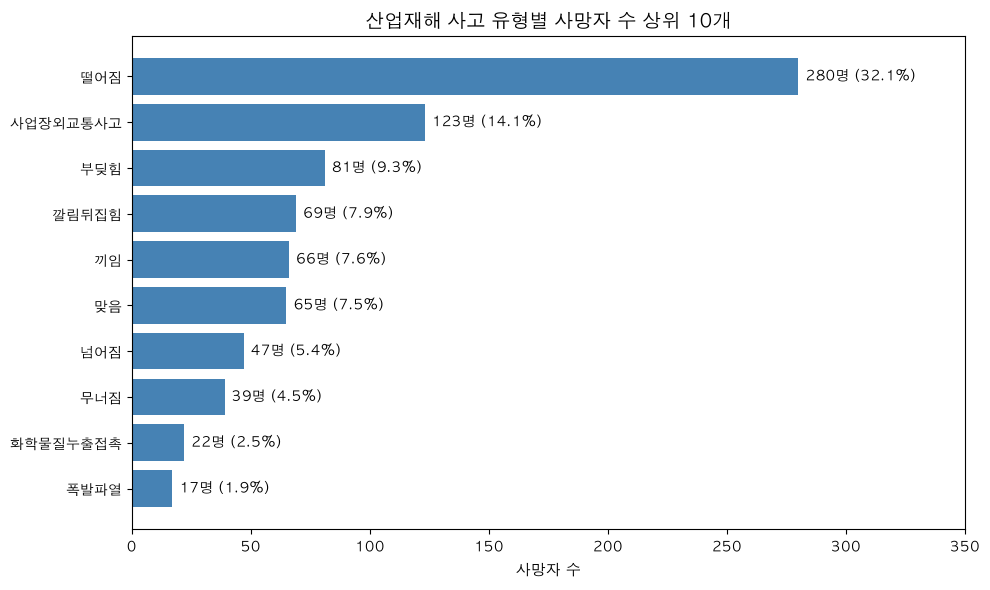

In [18]:
plt.rcParams["font.family"] = "AppleGothic"                        # 맥에서 한글이 깨지지 않도록 글꼴 설정
plt.rcParams["axes.unicode_minus"] = False                         # 마이너스 기호 깨짐 방지

top10 = incident_summary.head(10).sort_values("사망자수")            # 사망자 수 상위 10개를 적은 순서부터 정렬

plt.figure(figsize=(10, 6))                                        # 가로 10인치, 세로 6인치 그래프 생성
bars = plt.barh(top10.index, top10["사망자수"], color="steelblue")   # 사고 유형별 가로 막대그래프 생성

for bar, pct in zip(bars, top10["비율(%)"]):                        # 각 막대와 해당 사고 비율을 차례로 가져오기
    count = int(bar.get_width())                                   # 막대 길이에서 사망자 수 가져오기
    x = count + 3                                                  # 설명을 표시할 가로 위치
    y = bar.get_y() + bar.get_height() / 2                         # 막대의 세로 중앙 위치
    plt.text(x, y, f"{count}명 ({pct}%)", va="center")              # 막대 오른쪽에 사망자 수와 비율 표시

plt.title("산업재해 사고 유형별 사망자 수 상위 10개", fontsize=14)          # 그래프 제목
plt.xlabel("사망자 수", fontsize=11)                                              # 가로축 이름
plt.xlim(0, top10["사망자수"].max() * 1.25)                          # 오른쪽 글자가 잘리지 않도록 범위 확장
plt.tight_layout()                                                 # 글자와 그래프의 겹침 방지
plt.savefig("../outputs/images/accident_type_top10.png", dpi=300, bbox_inches="tight")  # 그래프를 고해상도 이미지로 저장
plt.show()                                                         # 주피터 화면에 그래프 출력

## 3. 업종별 사망자 분석

대업종과 중업종별 사고성 사망자 수를 비교하여 사망사고가 집중되는 산업군을 확인합니다.

대업종별 사고성 사망자 수:


,사망자수,비율(%)
대업종,,
건설업,361,41.4
운수·창고·통신업,176,20.2
제조업,164,18.8
기타의사업,140,16.1
임 업,18,2.1
광 업,6,0.7
농 업,5,0.6
전기·가스·증기·수도사업,2,0.2
금융및보험업,0,0.0


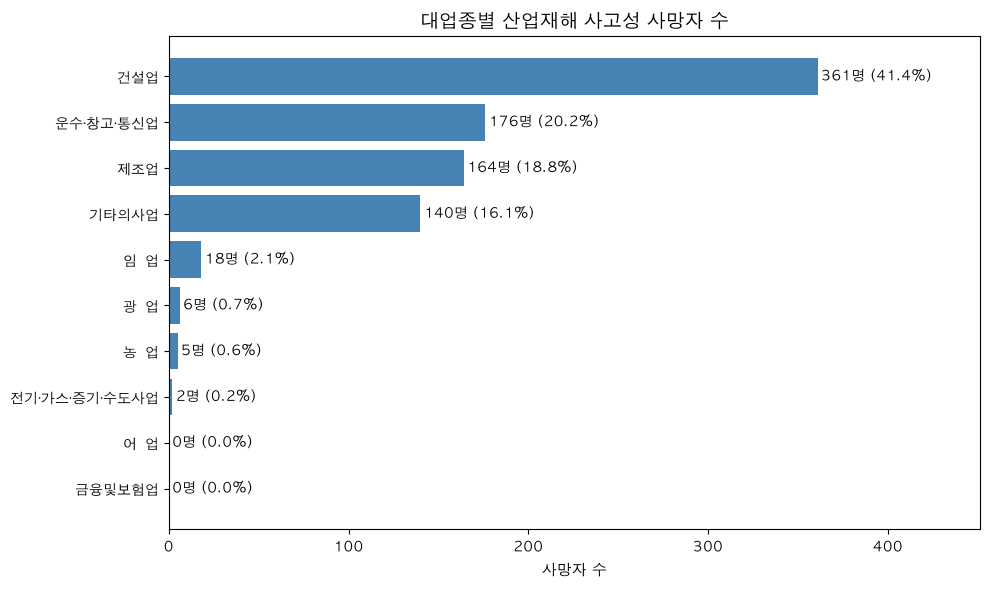

In [19]:
industry_totals = df.groupby("대업종")[incident_totals.index].sum().sum(axis=1)    # 대업종별 사고 유형을 합산
industry_totals = industry_totals.sort_values(ascending=False)                   # 사망자 수가 많은 순서로 정렬

industry_summary = pd.DataFrame({                                                # 분석 결과를 표 형태로 생성
    "사망자수": industry_totals,
    "비율(%)": (industry_totals / industry_totals.sum() * 100).round(1)
})

print("대업종별 사고성 사망자 수:")                                                    # 결과 안내 문구 출력
display(industry_summary)                                                        # 대업종별 사망자 수와 비율 출력

plot_data = industry_summary.sort_values("사망자수")                               # 가로 막대그래프용 오름차순 정렬
plt.figure(figsize=(10, 6))                                                      # 그래프 크기 설정
bars = plt.barh(plot_data.index, plot_data["사망자수"], color="steelblue")        # 대업종별 가로 막대그래프 생성

for bar, pct in zip(bars, plot_data["비율(%)"]):                                  # 막대와 비율을 차례대로 가져오기
    count = int(bar.get_width())                                                 # 막대 길이에서 사망자 수 가져오기
    plt.text(count + 2, bar.get_y() + bar.get_height() / 2, f"{count}명 ({pct}%)", va="center")  # 수치 표시

plt.title("대업종별 산업재해 사고성 사망자 수", fontsize=14)                              # 그래프 제목
plt.xlabel("사망자 수", fontsize=11)                                                             # 가로축 이름
plt.xlim(0, plot_data["사망자수"].max() * 1.25)                                     # 오른쪽 설명 공간 확보
plt.tight_layout()                                                                # 그래프 요소가 겹치지 않도록 조정
plt.savefig("../outputs/images/deaths_by_industry.png", dpi=300, bbox_inches="tight")  # 그래프 이미지 저장
plt.show()                                                                        # 주피터 화면에 그래프 출력

중업종별 사고성 사망자 수 상위 10개:


,사망자수,비율(%)
중업종,,
건설업,361,41.4
육상및수상운수업,141,16.2
기계기구·금속·비금속광물제품제조업,90,10.3
시설관리및사업지원서비스업,64,7.3
철도·항공·창고·운수관련서비스업,35,4.0
전문·보건·교육·여가관련서비스업,30,3.4
도소매·음식·숙박업,28,3.2
화학및고무제품제조업,21,2.4
임업,18,2.1


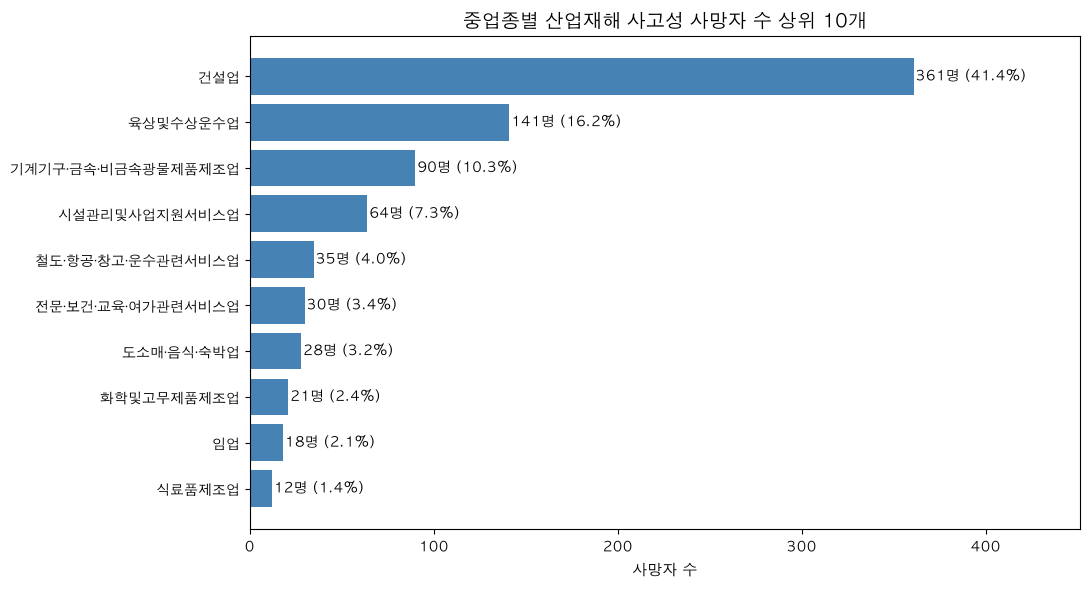

In [20]:
subindustry_totals = df.groupby("중업종")[incident_totals.index].sum().sum(axis=1)     # 중업종별 사고성 사망자 수 합산
subindustry_totals = subindustry_totals.sort_values(ascending=False)                 # 사망자 수가 많은 순서로 정렬

subindustry_summary = pd.DataFrame({                                                 # 사망자 수와 비율을 표로 생성
    "사망자수": subindustry_totals,
    "비율(%)": (subindustry_totals / subindustry_totals.sum() * 100).round(1)
})

print("중업종별 사고성 사망자 수 상위 10개:")                                               # 결과 안내 문구 출력
display(subindustry_summary.head(10))                                               # 상위 10개 중업종 출력

top10_subindustry = subindustry_summary.head(10).sort_values("사망자수")               # 그래프용 오름차순 정렬
plt.figure(figsize=(11, 6))                                                          # 그래프 크기 설정
bars = plt.barh(top10_subindustry.index, top10_subindustry["사망자수"], color="steelblue")  # 가로 막대그래프 생성

for bar, pct in zip(bars, top10_subindustry["비율(%)"]):                              # 막대와 비율을 하나씩 가져오기
    count = int(bar.get_width())                                                     # 막대 길이에서 사망자 수 가져오기
    plt.text(count + 1, bar.get_y() + bar.get_height() / 2, f"{count}명 ({pct}%)", va="center")  # 수치 표시

plt.title("중업종별 산업재해 사고성 사망자 수 상위 10개", fontsize=14)                                      # 그래프 제목
plt.xlabel("사망자 수", fontsize=11)                                                               # 가로축 이름
plt.xlim(0, top10_subindustry["사망자수"].max() * 1.25)                                # 오른쪽 설명 공간 확보
plt.tight_layout()                                                                   # 글자와 그래프가 겹치지 않도록 조정
plt.savefig("../outputs/images/deaths_by_subindustry_top10.png", dpi=300, bbox_inches="tight")  # 이미지 저장
plt.show()                                                                           # 그래프 출력

## 4. 사업장 규모별 사망자 분석

사업장 규모별 사고성 사망자 수를 비교하여 사망사고가 집중되는 사업장 규모를 확인합니다.

사업장 규모별 사고성 사망자 수:


,사망자수,비율(%)
규모,,
5인 미만,354,40.6
5인 ~ 9인,107,12.3
10인 ~ 19인,113,13.0
20인 ~ 29인,49,5.6
30인 ~ 49인,63,7.2
50인 ~ 99인,47,5.4
100인 ~ 299인,74,8.5
300인 ~ 499인,12,1.4
500인 ~ 999인,19,2.2


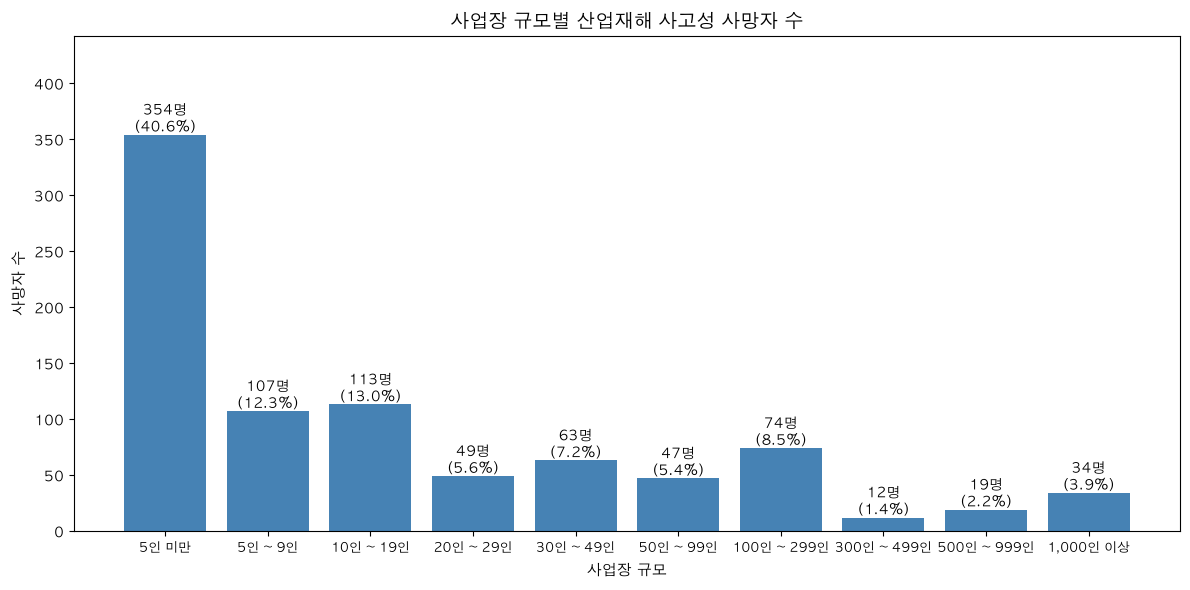

In [21]:
size_order = ["5인 미만", "5인 ~ 9인", "10인 ~ 19인", "20인 ~ 29인", "30인 ~ 49인", "50인 ~ 99인", "100인 ~ 299인", "300인 ~ 499인", "500인 ~ 999인", "1,000인 이상"]  # 사업장 규모 순서

size_totals = df.groupby("규모")[incident_totals.index].sum().sum(axis=1)            # 규모별 사고성 사망자 수 합산
size_totals = size_totals.reindex(size_order)                                       # 사업장 규모가 작은 순서로 재배치

size_summary = pd.DataFrame({                                                       # 사망자 수와 비율을 표로 생성
    "사망자수": size_totals,
    "비율(%)": (size_totals / size_totals.sum() * 100).round(1)
})

print("사업장 규모별 사고성 사망자 수:")                                                          # 결과 안내 문구 출력
display(size_summary)                                                                      # 규모별 사망자 수와 비율 출력

plt.figure(figsize=(12, 6))                                                                # 그래프 크기 설정
bars = plt.bar(size_summary.index, size_summary["사망자수"], color="steelblue")              # 규모별 세로 막대그래프 생성

for bar, pct in zip(bars, size_summary["비율(%)"]):                                         # 막대와 비율을 하나씩 가져오기
    count = int(bar.get_height())                                                          # 막대 높이에서 사망자 수 가져오기
    plt.text(bar.get_x() + bar.get_width() / 2, count + 3, f"{count}명\n({pct}%)", ha="center")  # 막대 위에 수치 표시

plt.title("사업장 규모별 산업재해 사고성 사망자 수", fontsize=14)                                                 # 그래프 제목
plt.xlabel("사업장 규모", fontsize=11)                                                                     # 가로축 이름
plt.ylabel("사망자 수", fontsize=11)                                                                      # 세로축 이름
plt.xticks(rotation=0, fontsize=9)  # 글씨를 수평으로 표시하고 크기를 조금 줄임
plt.ylim(0, size_summary["사망자수"].max() * 1.25)                                           # 막대 위 설명 공간 확보
plt.tight_layout()                                                                         # 글자와 그래프가 겹치지 않도록 조정
plt.savefig("../outputs/images/deaths_by_company_size.png", dpi=300, bbox_inches="tight")  # 이미지 저장
plt.show()                                                                                 # 그래프 출력

## 5. 사업장 규모별 사고 유형 분석

사업장 규모별 주요 사고 유형을 비교하여 규모에 따라 어떤 사고가 많이 발생하는지 확인합니다.

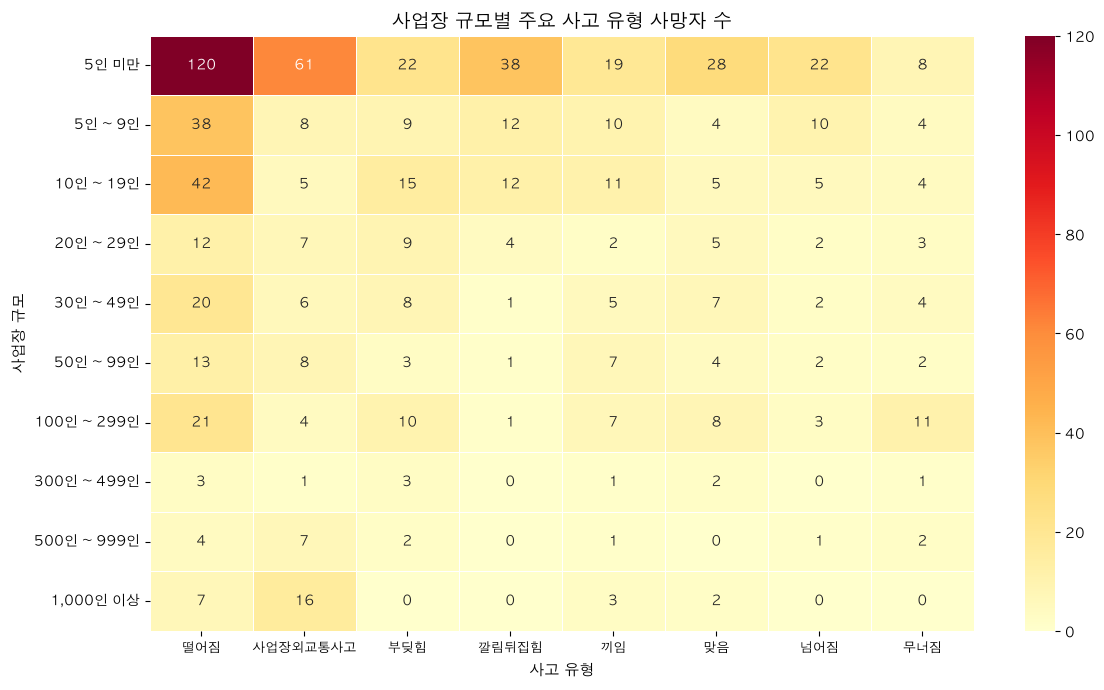

In [22]:
top8_types = incident_totals.head(8).index                                          # 사고성 사망자 수가 많은 사고 유형 8개 선택
size_accident = df.groupby("규모")[top8_types].sum()                                 # 규모별로 사고 유형의 사망자 수 합산
size_accident = size_accident.reindex(size_order)                                   # 5인 미만부터 1,000인 이상 순서로 정렬

plt.figure(figsize=(12, 7))                                                         # 히트맵 크기 설정
sns.heatmap(size_accident, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)      # 값과 색상으로 사망자 수 표시
plt.title("사업장 규모별 주요 사고 유형 사망자 수", fontsize=14)                                          # 그래프 제목
plt.xlabel("사고 유형", fontsize=11)                                                               # 가로축 이름
plt.ylabel("사업장 규모", fontsize=11)                                                             # 세로축 이름
plt.xticks(rotation=0, fontsize=9)                                                 # 사고 유형을 수평으로 표시
plt.yticks(rotation=0)                                                             # 사업장 규모를 수평으로 표시
plt.tight_layout()                                                                 # 글자와 그래프가 겹치지 않도록 조정
plt.savefig("../outputs/images/accident_heatmap_by_size.png", dpi=300, bbox_inches="tight")  # 이미지 저장
plt.show()                                                                         # 히트맵 출력

## 6. 50인 미만 사업장 집중도 분석

50인 미만 사업장의 사고성 사망자 수와 전체 대비 비율을 계산하여 소규모 사업장에 사망사고가 얼마나 집중되어 있는지 확인합니다.

In [23]:
small_sizes = ["5인 미만", "5인 ~ 9인", "10인 ~ 19인", "20인 ~ 29인", "30인 ~ 49인"]  # 50인 미만 규모 목록
small_deaths = size_summary.loc[small_sizes, "사망자수"].sum()                      # 50인 미만 사업장의 사고성 사망자 수 합계
total_deaths = size_summary["사망자수"].sum()                                      # 전체 사고성 사망자 수
small_ratio = small_deaths / total_deaths * 100                                    # 50인 미만 사업장의 사망자 비율 계산

top3_deaths = incident_summary.head(3)["사망자수"].sum()                            # 상위 3개 사고 유형의 사망자 수 합계
top3_ratio = top3_deaths / total_deaths * 100                                       # 상위 3개 사고 유형의 비율 계산

top_industry = industry_summary.index[0]                                            # 사고성 사망자가 가장 많은 대업종
top_industry_deaths = industry_summary.iloc[0]["사망자수"]                          # 해당 대업종의 사망자 수
top_subindustry = subindustry_summary.index[0]                                      # 사고성 사망자가 가장 많은 중업종
top_subindustry_deaths = subindustry_summary.iloc[0]["사망자수"]                    # 해당 중업종의 사망자 수

print(f"전체 사고성 사망자 수: {total_deaths:,}명")                                # 전체 사고성 사망자 수 출력
print(f"50인 미만 사업장 사망자 수: {small_deaths:,}명 ({small_ratio:.1f}%)")        # 소규모 사업장 비중 출력
print(f"상위 3개 사고 유형 비중: {top3_deaths:,}명 ({top3_ratio:.1f}%)")             # 주요 사고 유형 집중도 출력
print(f"사망자가 가장 많은 대업종: {top_industry} ({top_industry_deaths:,}명)")       # 위험도가 높은 대업종 출력
print(f"사망자가 가장 많은 중업종: {top_subindustry} ({top_subindustry_deaths:,}명)") # 위험도가 높은 중업종 출력

전체 사고성 사망자 수: 872명
50인 미만 사업장 사망자 수: 686명 (78.7%)
상위 3개 사고 유형 비중: 484명 (55.5%)
사망자가 가장 많은 대업종: 건설업 (361.0명)
사망자가 가장 많은 중업종: 건설업 (361.0명)


## 7. 주요 업종의 사고 유형 분석

사고성 사망자가 가장 많은 업종을 대상으로 사고 유형별 사망자 수와 비율을 분석하여 주요 위험 요인을 확인합니다.

건설업 사고 유형별 사망자 수 상위 10개:


,사망자수,비율(%)
떨어짐,185,51.2
부딪힘,37,10.2
맞음,32,8.9
무너짐,29,8.0
깔림뒤집힘,24,6.6
넘어짐,9,2.5
끼임,8,2.2
폭발파열,6,1.7
빠짐익사,6,1.7
감전,6,1.7


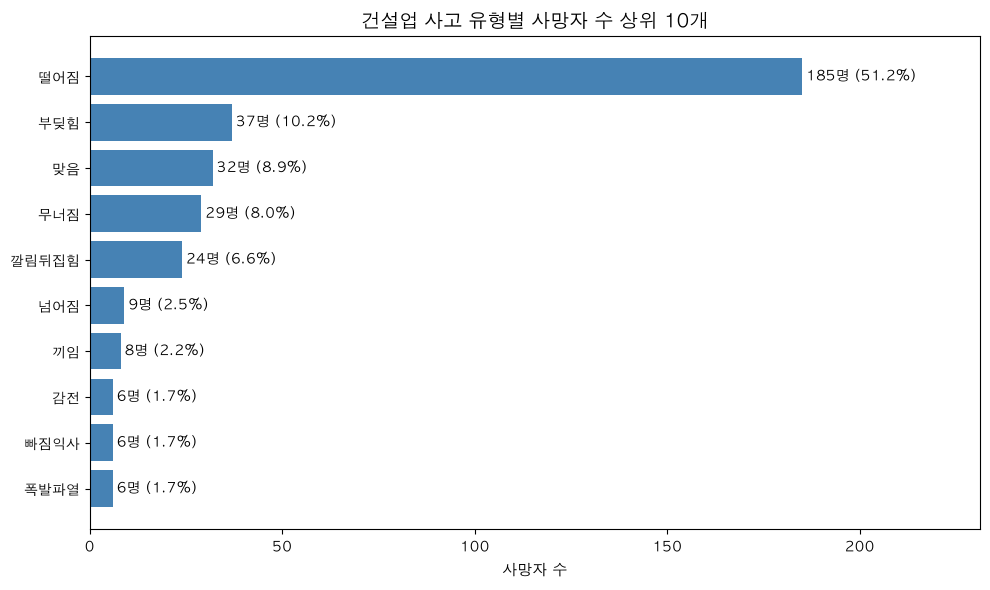

In [24]:
top_industry_data = df[df["대업종"] == top_industry]                              # 사망자가 가장 많은 대업종의 행만 선택
top_industry_types = top_industry_data[incident_totals.index].sum().sort_values(ascending=False)  # 사고 유형별 사망자 수 합산
top_industry_total = top_industry_types.sum()                                     # 해당 대업종의 전체 사고성 사망자 수

top_industry_summary = pd.DataFrame({                                             # 사고 유형별 사망자 수와 비율을 표로 생성
    "사망자수": top_industry_types,
    "비율(%)": (top_industry_types / top_industry_total * 100).round(1)
})

print(f"{top_industry} 사고 유형별 사망자 수 상위 10개:")                        # 분석 대상 대업종 출력
display(top_industry_summary.head(10))                                            # 상위 10개 사고 유형을 표로 출력

plot_data = top_industry_summary.head(10).sort_values("사망자수")                 # 그래프용 오름차순 정렬
plt.figure(figsize=(10, 6))                                                       # 그래프 크기 설정
bars = plt.barh(plot_data.index, plot_data["사망자수"], color="steelblue")         # 사고 유형별 가로 막대그래프 생성

for bar, pct in zip(bars, plot_data["비율(%)"]):                                  # 막대와 비율을 하나씩 가져오기
    count = int(bar.get_width())                                                  # 막대 길이에서 사망자 수 가져오기
    plt.text(count + 1, bar.get_y() + bar.get_height() / 2, f"{count}명 ({pct}%)", va="center")  # 막대 옆에 수치 표시

plt.title(f"{top_industry} 사고 유형별 사망자 수 상위 10개", fontsize=14)                    # 선택된 대업종 이름을 제목에 사용
plt.xlabel("사망자 수", fontsize=11)                                                          # 가로축 이름
plt.xlim(0, plot_data["사망자수"].max() * 1.25)                                   # 오른쪽 설명 공간 확보
plt.tight_layout()                                                                # 글자와 그래프가 겹치지 않도록 조정
plt.savefig("../outputs/images/top_industry_accident_types.png", dpi=300, bbox_inches="tight")  # 이미지 저장
plt.show()                                                                        # 그래프 출력

## 8. 분석 결과 저장

분석한 사고 유형, 업종, 사업장 규모별 결과를 CSV 파일로 저장하여 이후 보고서 작성이나 추가 분석에 활용할 수 있도록 정리합니다.

In [25]:
from pathlib import Path                                                          # 폴더와 파일 경로를 안전하게 다루는 기능 불러오기

table_dir = Path("../outputs/tables")                                             # 분석 결과표를 저장할 폴더 경로
table_dir.mkdir(parents=True, exist_ok=True)                                      # 폴더가 없으면 생성하고, 이미 있으면 그대로 사용

incident_summary.to_csv(table_dir / "accident_type_summary.csv", encoding="utf-8-sig")           # 사고 유형별 결과 저장
industry_summary.to_csv(table_dir / "industry_summary.csv", encoding="utf-8-sig")                # 대업종별 결과 저장
subindustry_summary.to_csv(table_dir / "subindustry_summary.csv", encoding="utf-8-sig")          # 중업종별 결과 저장
size_summary.to_csv(table_dir / "company_size_summary.csv", encoding="utf-8-sig")                # 사업장 규모별 결과 저장
top_industry_summary.to_csv(table_dir / "top_industry_accident_summary.csv", encoding="utf-8-sig")  # 건설업 사고 유형 결과 저장

print("분석 결과표 저장 완료")                                                    # 저장이 끝났다는 문구 출력
print("저장 위치:", table_dir)                                                    # 결과표가 저장된 폴더 출력

분석 결과표 저장 완료
저장 위치: ../outputs/tables


## 9. 분석 결과 요약

- 전체 사망자 **2,248명** 중 업무상질병을 제외한 사고성 사망자는 **872명**입니다.
- 사고성 사망 원인 중 **떨어짐 280명(32.1%)**으로 가장 높은 비중을 차지했습니다.
- 상위 3개 사고 유형이 전체 사고성 사망자의 **55.5%**를 차지했습니다.
- **50인 미만 사업장 686명(78.7%)**으로 소규모 사업장에 사고성 사망자가 집중되었습니다.
- 대업종 중 **건설업 361명**으로 사고성 사망자가 가장 많았습니다.
- 건설업에서도 **떨어짐 사고**가 주요 사망 원인으로 나타났습니다.

## 10. 분석 결론

분석 결과 산업재해 사고성 사망자는 **50인 미만 사업장과 건설업에 집중**되어 있었습니다.

특히 **떨어짐 사고가 주요 사망 원인**으로 확인되어, 소규모 사업장과 건설 현장을 중심으로 추락 방지시설 점검과 보호구 착용 관리 등을 강화할 필요가 있습니다.